# Example notebook to explore the dataset collections provided in WP2-ICDR-O3-LP-v2

### Setup
First we import the necessary libraries and set a few parameters based on the Delivery Note information, provided in COPCO-1060

In [28]:
import xarray as xr 
import matplotlib.pyplot as plt
import os
import cartopy
import numpy as np
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
import matplotlib as mpl
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import datetime
import cdsapi
import zipfile 
import pandas as pd
import requests
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Delivery settings

manifest_file = 'https://wdc.dlr.de/C3S_312b_Lot2/manifest_C3S_312b_Lot2_O3_MONTHLY_2026-02-27.txt'

# set product parameters in a dictionary. adjust for future versions / additional products
product_parameters = {
    'OSIRIS': {
        'sensor_line'         : 'LP', 
        'satellite'           : 'ODIN',   # make sure to use the correct satellite name as per the manifest file
        'instrument'          : 'OSIRIS', # make sure to use the correct instrument name as per the manifest file
        'algorithm'           : 'ALG',    # trying to make this generic enough. most datasets only have a generic 'ALG'
        'version'             : 'v0003',  # make sure to use the correct version as per the manifest file
        'delivery_start'      : pd.Timestamp('01/12/2024'), # start date of *this* delivery
        'delivery_end'        : pd.Timestamp('30/11/2025'),
        'collection_start'    : pd.Timestamp('01/11/2001'), # start date of the *whole* dataset
        'collection_end'      : pd.Timestamp('30/11/2025'),
        'temporal_resolution' : 'MS', # frequency_code = 'MS' # 'D' for daily, 'MS' for monthly, 'AS' for annual
        'parameter_list'      : ['ozone_concentration']
    },
}

product = 'OSIRIS'
sensor_line         = product_parameters[product]['sensor_line']
satellite           = product_parameters[product]['satellite']
instrument          = product_parameters[product]['instrument']
algorithm           = product_parameters[product]['algorithm']
version             = product_parameters[product]['version']
delivery_start      = product_parameters[product]['delivery_start']
delivery_end        = product_parameters[product]['delivery_end']
collection_start    = product_parameters[product]['collection_start']
collection_end      = product_parameters[product]['collection_end']
temporal_resolution = product_parameters[product]['temporal_resolution']
parameter_list      = product_parameters[product]['parameter_list']

# options for download
download_full_dataset = True # download full CDR or not
download_delivery     = True # download files for this delivery
# directory where we will store the datasets
work_dir = f'/perm/cxjo/datasets/Ozone/{product}/' 
clean_workdir = False        # set if we should delete all the files in the work dir before we start or not

if not os.path.exists(work_dir):
    print(work_dir)
    os.makedirs(work_dir)

if (clean_workdir):
    os.remove(f'{work_dir}/*') # clean directory before we start working (if desired)


### Download manifest file and get list of file URLs to download corresponding to the delivery

In [29]:
# Download manifest file and get list of file URLs to download corresponding to the delivery
local_manif_fname = os.path.basename(manifest_file)
r = requests.get(manifest_file)
with open(local_manif_fname, 'w') as file:
    file.write(r.text)

# now read the manifest file and print the lines corresponding to the satellite and instrument of interest    
with open(local_manif_fname,'r') as file:                                                                                                                                                                                                                                             
    for line in file:
        if satellite in line and instrument in line and version in line and algorithm in line and sensor_line in line:
            print(line)
            


http://wdc.dlr.de/C3S_312b_Lot2/O3/LP/ODIN/OSIRIS/ALG/v0003/L3_MONTHLY/2001/200111-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc

http://wdc.dlr.de/C3S_312b_Lot2/O3/LP/ODIN/OSIRIS/ALG/v0003/L3_MONTHLY/2001/200112-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc

http://wdc.dlr.de/C3S_312b_Lot2/O3/LP/ODIN/OSIRIS/ALG/v0003/L3_MONTHLY/2002/200201-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc

http://wdc.dlr.de/C3S_312b_Lot2/O3/LP/ODIN/OSIRIS/ALG/v0003/L3_MONTHLY/2002/200202-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc

http://wdc.dlr.de/C3S_312b_Lot2/O3/LP/ODIN/OSIRIS/ALG/v0003/L3_MONTHLY/2002/200203-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc

http://wdc.dlr.de/C3S_312b_Lot2/O3/LP/ODIN/OSIRIS/ALG/v0003/L3_MONTHLY/2002/200204-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc

http://wdc.dlr.de/C3S_312b_Lot2/O3/LP/ODIN/OSIRIS/ALG/v0003/L3_MONTHLY/2002/200205-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc

http:/

First we define a function that will read the local copy of the manifest file and identify the lines corresponding to the data we are interested in.
We provide start and end dates, a frequency and the parameters defined in the beginning of the script that are unique to the dataset we are inspecting.
It will store the missing files into a list and print that list.
NOTE: We need to be very careful with the file pattern, as it might change for each collection.
It will return a list of existing files that will be useful below.
Then we call that function specifying the delivery dates as start and end dates.

In [30]:
def check_files_in_manifest(date_start, date_end, temporal_resolution,sensor_line,satellite, instrument, algorithm, version, manifest_file):
    # Create a date range
    date_range = pd.date_range(start=date_start, end=date_end, freq=temporal_resolution) # MS: month start frequency
    
    # Prepare the pattern for file names
    missing_files = []
    existing_files = []
    
    # Read the manifest file (assuming it's a list of filenames)
    with open(manifest_file, 'r') as f:
        manifest_files = set(f.read().splitlines())  # Assuming one filename per line
    
    # Loop through the date range and generate the file pattern for each month
    for date in date_range:
        # Format the date in YYYYMM
        YYYYMM = date.strftime('%Y%m')
        # carefully inspect this file pattern:
        file_pattern = f"http://wdc.dlr.de/C3S_312b_Lot2/O3/{sensor_line}/{satellite}/{instrument}/{algorithm}/{version}/L3_MONTHLY/{YYYYMM[:4]}/{YYYYMM}-C3S-L3_OZONE-O3_PRODUCTS-{instrument}-{satellite}-ALG-MONTHLY-{version}.nc"
        
        # Check if the file is in the manifest
        if file_pattern not in manifest_files:
            missing_files.append(file_pattern)
        else:
            existing_files.append(file_pattern)
    
    if missing_files:
        nmissing = len(missing_files)
        print(f"Missing files for the following {nmissing} date(s):")
        for file in missing_files:
            print(file)
    else:
        print("All expected dates are present in the manifest file.")
        print('Dates:', existing_files)
        
    return existing_files

        
file_list = check_files_in_manifest(delivery_start, delivery_end, temporal_resolution,sensor_line,satellite, instrument, algorithm, version, local_manif_fname)


Missing files for the following 1 date(s):
http://wdc.dlr.de/C3S_312b_Lot2/O3/LP/ODIN/OSIRIS/ALG/v0003/L3_MONTHLY/2025/202506-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc


Then we download the data we need to proceed with the analysis.
We might wish to download only the ICDR we are inspecting, or the full CDR + ICDRs for this dataset version.

In [31]:
if download_delivery:
    for file in file_list:
        local_fname = work_dir + os.path.basename(file)
        print(local_fname)
        if os.path.exists(local_fname):
            print(f"Already exists: {local_fname}")
            continue
        print(f"Downloading {file}")
        with requests.get(file, stream=True) as r:
            r.raise_for_status()
            with open(local_fname, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
                        
if download_full_dataset:
    file_list_full = check_files_in_manifest(collection_start, collection_end, temporal_resolution,sensor_line,satellite, instrument, algorithm, version, local_manif_fname)
    for file in file_list_full:
        local_fname = work_dir + os.path.basename(file)
        print(local_fname)
        if os.path.exists(local_fname):
            print(f"Already exists: {local_fname}")
            continue
        print(f"Downloading {file}")
        with requests.get(file, stream=True) as r:
            r.raise_for_status()
            with open(local_fname, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
                

/perm/cxjo/datasets/Ozone/OSIRIS/202402-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /perm/cxjo/datasets/Ozone/OSIRIS/202402-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
/perm/cxjo/datasets/Ozone/OSIRIS/202403-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /perm/cxjo/datasets/Ozone/OSIRIS/202403-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
/perm/cxjo/datasets/Ozone/OSIRIS/202404-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /perm/cxjo/datasets/Ozone/OSIRIS/202404-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
/perm/cxjo/datasets/Ozone/OSIRIS/202405-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /perm/cxjo/datasets/Ozone/OSIRIS/202405-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
/perm/cxjo/datasets/Ozone/OSIRIS/202406-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /perm/cxjo/datasets/Ozone/OSIRIS/20240

Already exists: /perm/cxjo/datasets/Ozone/OSIRIS/202501-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
/perm/cxjo/datasets/Ozone/OSIRIS/202502-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /perm/cxjo/datasets/Ozone/OSIRIS/202502-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
/perm/cxjo/datasets/Ozone/OSIRIS/202503-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /perm/cxjo/datasets/Ozone/OSIRIS/202503-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
/perm/cxjo/datasets/Ozone/OSIRIS/202504-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /perm/cxjo/datasets/Ozone/OSIRIS/202504-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
/perm/cxjo/datasets/Ozone/OSIRIS/202505-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
Already exists: /perm/cxjo/datasets/Ozone/OSIRIS/202505-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
/perm/cxjo/datasets/Ozone/OSIRIS/20250

## Dataset inspection
### Check metadata 
Open a random file from the collection and display its contents and attributes (in this case last file in the list)

In [32]:

fname = work_dir + os.path.basename(file_list[-1]) # last file of the list of existing files, for example.
print(fname)
nc = xr.open_dataset(fname)
print(nc.info())


/perm/cxjo/datasets/Ozone/OSIRIS/202511-C3S-L3_OZONE-O3_PRODUCTS-OSIRIS-ODIN-ALG-MONTHLY-v0003.nc
xarray.Dataset {
dimensions:
	latitude_centers = 18 ;
	altitude = 59 ;

variables:
	float32 latitude_centers(latitude_centers) ;
		latitude_centers:units = degrees_north ;
		latitude_centers:standard_name = latitude ;
		latitude_centers:long_name = centers of latitude bins ;
	float32 altitude(altitude) ;
		altitude:units = km ;
		altitude:standard_name = altitude ;
		altitude:long_name = geometric altitude ;
	float64 ozone_concentration(altitude, latitude_centers) ;
		ozone_concentration:units = mol m-3 ;
		ozone_concentration:standard_name = mole_concentration_of_ozone_in_air ;
		ozone_concentration:long_name = monthly zonal mean ozone concentration ;
		ozone_concentration:multiplication_factor_to_convert_to_molecules_percm3 = 6.022140857E+17 ;
		ozone_concentration:multiplication_factor_to_convert_to_DU_perkm = 2.24115E+06 ;
	float32 standard_error_of_the_mean(altitude, latitude_centers)

Now lets produce visualisations of the datasets we are interested in.
For LP, we have latitude-height cross-sections, so the visualisations here are very specific for this sensor line

In [33]:
# list of local filenames
flist_local = [work_dir + os.path.basename(file_list[i]) for i in range(len(file_list))]

def preprocess(ds):
    filename = ds.encoding["source"]
    yyyymm = os.path.basename(filename)[:6]
    time = pd.to_datetime(yyyymm, format="%Y%m")
    return ds.expand_dims(time=[time])

ds_all = xr.open_mfdataset(
    flist_local,
    preprocess=preprocess,
    concat_dim="time",
    combine="nested"
)

date_range = pd.date_range(start=delivery_start, end=delivery_end, freq=temporal_resolution) # MS: month start frequency
ds_all = ds_all.reindex(time=date_range)

from matplotlib.animation import FuncAnimation
from IPython.display import HTML


# Extract arrays
ozone = ds_all["ozone_concentration"].values
lat = ds_all["latitude_centers"].values
alt = ds_all["altitude"].values
times = ds_all["time"].values

# Create figure
fig, ax = plt.subplots(figsize=(8,5))

# Initial frame
im = ax.imshow(
    ozone[0],
    origin="lower",
    aspect="auto",
    extent=[lat.min(), lat.max(), alt.min(), alt.max()],
    cmap="viridis"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f'{ds_all.ozone_concentration.long_name}'+' / '+ f'{ds_all.ozone_concentration.units}')

ax.set_xlabel("Latitude")
ax.set_ylabel(f'{ds_all.altitude.long_name}'+' / '+ f'{ds_all.altitude.units}')
title = ax.set_title(str(times[0]))

# Update function
def update(frame):
    im.set_array(ozone[frame])
    title.set_text(np.datetime_as_string(times[frame], unit='M'))
    return im, title

# Create animation
ani = FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=500,
    blit=False
)

plt.close(fig)

HTML(ani.to_jshtml())

# ds_all["ozone_concentration"].hvplot.quadmesh(
#     x="latitude_centers",
#     y="altitude",
#     groupby="time",
#     cmap="viridis",
#     rasterize=True,
#     frame_width=700,
#     frame_height=400
# )


## Examine missing values and ozone distribution

/etc/ecmwf/ssd/ssd1/tmpdirs/cxjo.1920991.20260312_111536.795/ipykernel_728361/2665349123.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_cells = ds_all.dims["latitude_centers"] * ds_all.dims["altitude"]


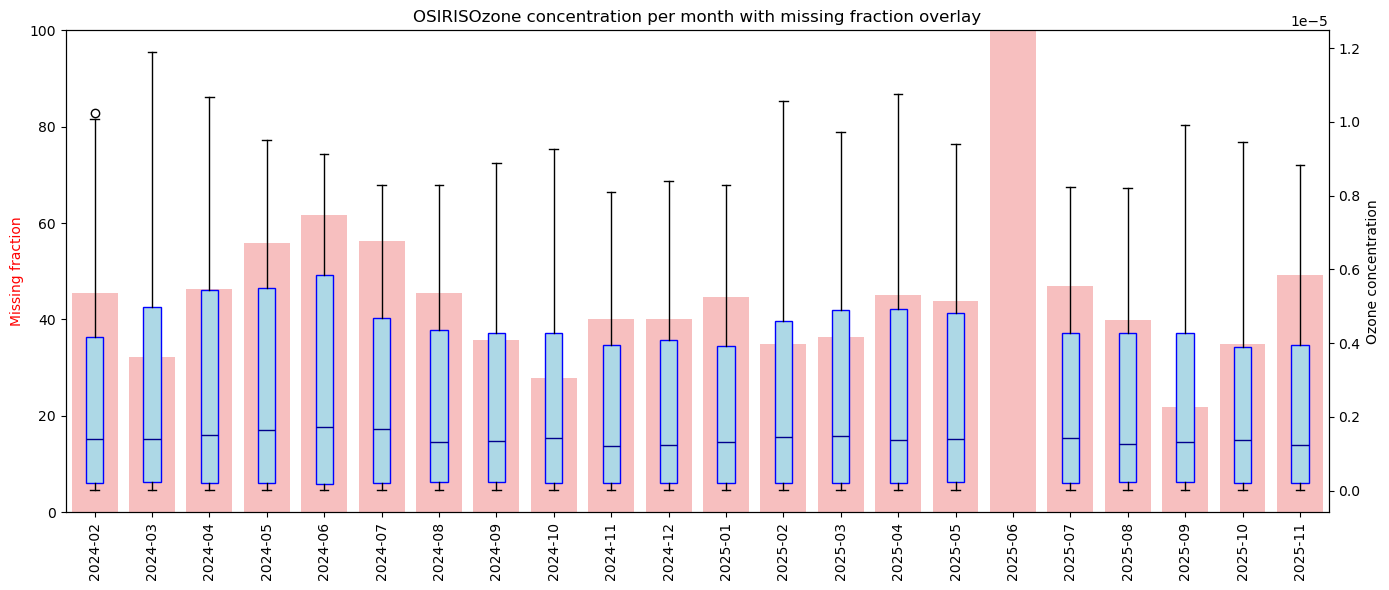

In [34]:
monthly_data = []

for i in range(len(ds_all.time)):
    month_values = ds_all["ozone_concentration"].isel(time=i).values.flatten()
    # keep only valid numbers
    month_values = month_values[~np.isnan(month_values)]
    monthly_data.append(month_values)

months = pd.to_datetime(ds_all.time.values).strftime("%Y-%m")
x_pos = np.arange(len(months))

fig, ax1 = plt.subplots(figsize=(14,6))

# Bar chart: missing fraction
total_cells = ds_all.dims["latitude_centers"] * ds_all.dims["altitude"]
missing_count = ds_all["ozone_concentration"].isnull().sum(dim=("latitude_centers","altitude"))
missing_fraction = missing_count / total_cells *100

ax1.bar(x_pos, missing_fraction, color="lightcoral", alpha=0.5, label="Missing fraction")
ax1.set_ylabel("Missing fraction", color="red")
ax1.set_ylim(0, 100)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(months, rotation=90)

# Boxplot: ozone concentration
ax2 = ax1.twinx()
# Only include months with data for the boxplot
valid_data = [d if len(d) > 0 else [np.nan] for d in monthly_data]
ax2.boxplot(valid_data, positions=x_pos, widths=0.3, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="blue"),
            medianprops=dict(color="darkblue"))
ax2.set_ylabel("Ozone concentration")
ax2.set_xticks(np.arange(len(monthly_data)))
ax2.set_xticklabels(months, rotation=90)

plt.title(f"{product}Ozone concentration per month with missing fraction overlay")
fig.tight_layout()
plt.show()

### Now we look into the full timeseries

/etc/ecmwf/ssd/ssd1/tmpdirs/cxjo.1920991.20260312_111536.795/ipykernel_728361/1396215300.py:64: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_cells = ds_all.dims["latitude_centers"] * ds_all.dims["altitude"]


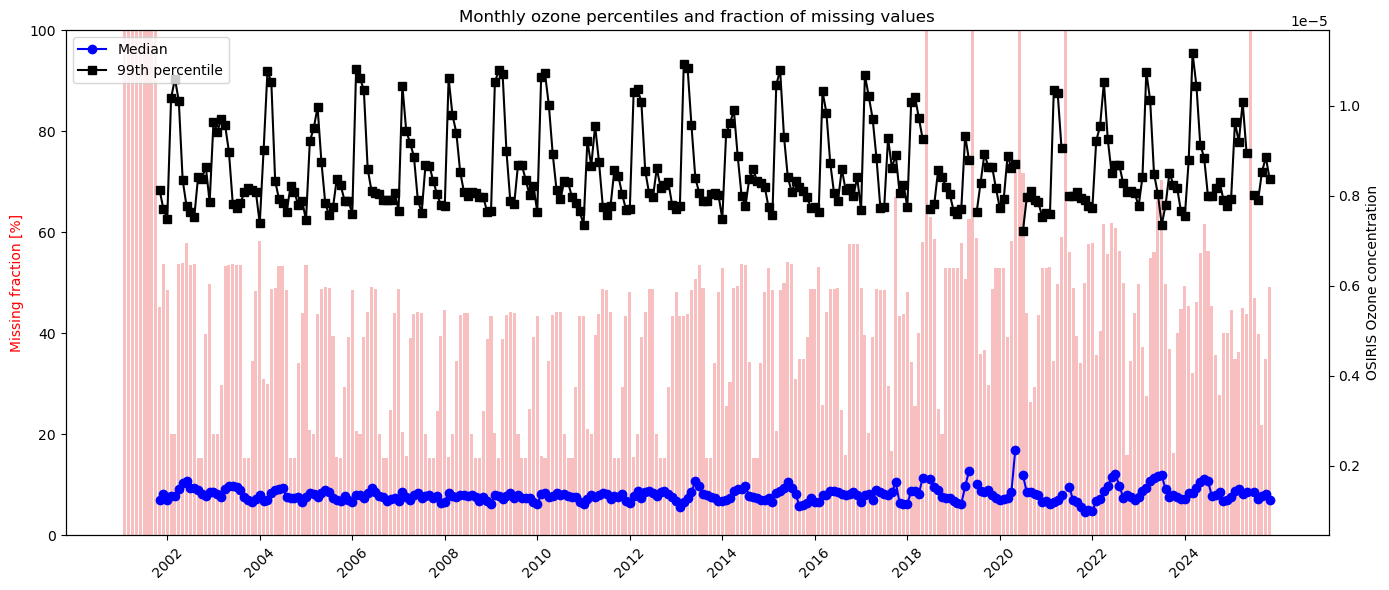

In [35]:
flist_local_full = [work_dir + os.path.basename(file_list_full[i]) for i in range(len(file_list_full))]

def preprocess(ds):
    filename = ds.encoding["source"]
    yyyymm = os.path.basename(filename)[:6]
    time = pd.to_datetime(yyyymm, format="%Y%m")
    return ds.expand_dims(time=[time])

ds_all = xr.open_mfdataset(
    flist_local_full,
    preprocess=preprocess,
    concat_dim="time",
    combine="nested"
)

date_range = pd.date_range(start=collection_start, end=collection_end, freq=temporal_resolution) # MS: month start frequency
ds_all = ds_all.reindex(time=date_range)


monthly_data = []

for i in range(len(ds_all.time)):
    month_values = ds_all["ozone_concentration"].isel(time=i).values.flatten()
    # keep only valid numbers
    month_values = month_values[~np.isnan(month_values)]
    monthly_data.append(month_values)

months = pd.to_datetime(ds_all.time.values).strftime("%Y-%m")
x_pos = np.arange(len(months))

# compute percentiles for all months in timeseries

# Percentiles to compute
pct = [50, 99]

# Store results
percentiles = {p: [] for p in pct}

# Flatten each month and compute percentiles
for i in range(len(ds_all.time)):
    month_values = ds_all["ozone_concentration"].isel(time=i).values.flatten()
    month_values = month_values[~np.isnan(month_values)]  # ignore NaNs
    if len(month_values) == 0:
        # if month is fully missing, use NaN
        for p in pct:
            percentiles[p].append(np.nan)
    else:
        for p in pct:
            percentiles[p].append(np.percentile(month_values, p))

# Convert to DataFrame for convenience
df_pct = pd.DataFrame(percentiles, index=pd.to_datetime(ds_all.time.values))



# x positions (one per month)
x_pos = np.arange(len(df_pct))

fig, ax1 = plt.subplots(figsize=(14,6))

# -----------------------------
# Bar chart: missing fraction
# -----------------------------
total_cells = ds_all.dims["latitude_centers"] * ds_all.dims["altitude"]
missing_count = ds_all["ozone_concentration"].isnull().sum(dim=("latitude_centers","altitude"))
missing_fraction = missing_count / total_cells * 100

ax1.bar(x_pos, missing_fraction, color="lightcoral", alpha=0.5, label="Missing fraction")
ax1.set_ylabel("Missing fraction [%]", color="red")
ax1.set_ylim(0, 100)
ax1.set_xticks(x_pos)
# Reduce X-axis labels: every other year
months = pd.to_datetime(ds_all.time.values)
xticks = months[months.month==1][::2]  # pick Jan every other year
xtick_pos = [x_pos[i] for i in range(len(months)) if months[i] in xticks]
ax1.set_xticks(xtick_pos)
ax1.set_xticklabels([d.year for d in xticks], rotation=45)

# -----------------------------
# Percentiles
# -----------------------------
ax2 = ax1.twinx()
colors = ["blue", "green", "black", "orange", "red"]

ax2.plot(x_pos, df_pct[50], marker="o", linestyle="-", color='blue', label=f"Median")
ax2.plot(x_pos, df_pct[99], marker="s", linestyle="-", color='black', label=f"{99}th percentile")

ax2.set_ylabel(f"{product} Ozone concentration")
ax2.set_title("Monthly ozone percentiles and fraction of missing values")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()